# This notebook computes surfboard and SSB from modeled spectra

In [35]:
import netCDF4 as nc
import glob
import xarray as xr
import numpy as np
import datetime
from matplotlib import pyplot as plt, animation
import matplotlib.gridspec as gridspec

from scipy import signal
from scipy.interpolate import RegularGridInterpolator

import os
import sys as sys
sys.path.append('../src/')
import swot_swell_utils as swell
from pathlib import Path
import paths
from  lib_filters_obp import *
from  spectral_analysis_functions import *

from wave_physics_functions import wavespec_Efth_to_Ekxky,wavespec_Ekxky_to_first3
import cmocean
import cmocean.cm as cmo
import matplotlib.colors as mcolors

from ipywidgets import interact, IntSlider, FloatRangeSlider,  FloatSlider, ToggleButtons
from ipywidgets import interactive_output, GridBox, Layout
from IPython.display import display
from ipywidgets import VBox


lightcmap = cmocean.tools.lighten(cmo.ice, 1)
lightcmap2 = cmocean.tools.lighten(cmo.ice_r, 1)


In [36]:
# A few useful numbers: orders of magnitude of kz for SWOT 
kz=785*10/(35000)
kz2=785*10/(15000)
kz3=785*10/(55000)
print(kz,2*np.pi/kz,kz2,2*np.pi/kz2,kz3,2*np.pi/kz3)
Hss=0.1
Ess=(Hss/4)**2
EssPSD=Ess/9/(0.0002**2)
print(Ess,EssPSD,10*np.log10(EssPSD))
print(2*np.pi/(8-2*np.pi))


0.22428571428571428 28.01420200653319 0.5233333333333333 12.00608657422851 0.14272727272727273 44.02231743883787
0.0006250000000000001 1736.1111111111113 32.39577516576788
3.659792366325487


In [37]:
# Load dataset with noise analysis results
dataset_folder='../data/noise_analysis_SWOT_tracks/'
navg=1
# uncomment one line below to choose your cases ... 

#ds_seg=xr.open_dataset(dataset_folder+"SWOT_segmentsL2_D_20km_calval_pass24.nc");m=8;n=8;
#ds_seg=xr.open_dataset(dataset_folder+"SWOT_segmentsL2_D_20km_calval_pass52.nc");m=8;n=8;
#ds_seg=xr.open_dataset(dataset_folder+"SWOT_segmentsL2_D_20km_calval_pass82.nc");m=8;n=8;
alpha=1.;beta=0.03
# case B and others 
strip0=181;seg0=0;ds_seg=xr.open_dataset(dataset_folder+'SWOT_segmentsL2_D_SR3_calval_pass28.nc');m=8;n=8;
strip0=123;seg0=3;
strip0=171;seg0=7;  # case F

extx=40;exty=41
#case G
m=8;n=8;strip0=11;seg0=6;ds_seg=xr.open_dataset(dataset_folder+'SWOT_segmentsL2_D_20km_calval_pass24.nc');
m=2;n=2;strip0=13;seg0=9;navg=2;ds_seg=xr.open_dataset(dataset_folder+'SWOT_segmentsL2_D_SR5_pass24.nc');extx=0;exty=0

#case H
#m=8;n=8;strip0=11;seg0=6;ds_seg=xr.open_dataset(dataset_folder+'SWOT_segmentsL2_D_20km_calval_pass52.nc');
#m=4;n=4;strip0=11;seg0=6;ds_seg=xr.open_dataset(dataset_folder+'SWOT_segmentsL2_D_20km10km_calval_pass52.nc');
m=2;n=2;strip0=13;seg0=9;navg=2;ds_seg=xr.open_dataset(dataset_folder+'SWOT_segmentsL2_D_SR5_pass52.nc');extx=0;exty=0

#case I
#m=8;n=8;strip0=12;seg0=28;ds_seg=xr.open_dataset(dataset_folder+'SWOT_segmentsL2_D_SR3_pass82.nc');
#m=4;n=4;strip0=12;seg0=28;ds_seg=xr.open_dataset(dataset_folder+'SWOT_segmentsL2_D_SR4_pass82.nc');extx=40;exty=42
#m=2;n=2;strip0=10;seg0=28;navg=2;ds_seg=xr.open_dataset(dataset_folder+'SWOT_segmentsL2_D_SR5_pass82.nc');extx=0;exty=0


#case M
#m=8;n=8;strip0=71;seg0=1;navg=0;ds_seg=xr.open_dataset(dataset_folder+'SWOT_segmentsL2_D_SR3_calval_pass03.nc');


nIG=19;
# These spectra co-located with SWOT are available at: 
pth_WW3_trck='/media/ardhuin/FabLinux/WW3-SWOT/GLOBIG/';runtag='GLOBIG';prefix='SWOTIG_WW3-GLOB-30M'

#ds_seg=xr.open_dataset("SWOT_segmentsL2_20km_calval_pass28_GQM.nc")
#pth_WW3_trck='/media/ardhuin/FabLinux/WW3-SWOT/GLOBAL_GQM_HRS/';runtag='GQM-HRS';prefix='WW3-GLOB-30M'


n_strip = ds_seg.sizes['strip_id']
n_seg   = ds_seg.sizes['segment_id']
nfy= ds_seg.sizes['fy']
nfx= ds_seg.sizes['fx']
print('size:',n_strip,n_seg,nfx,nfy)
dxdy=(250*235)


############ define data extent ###########
nX2=80
nY2=84
nxtile=nX2*2//m  # cross-track
nytile=nY2*2//n  # along-track
############################################

kx2s = ds_seg["fx2D"].as_numpy().values
ky2s = ds_seg["fy2D"].as_numpy().values
filter_PTR=ds_seg["filter_PTR"].as_numpy().values
filter_OBP=ds_seg["filter_OBP"].as_numpy().values


dkx=kx2s[0,1]-kx2s[0,0]
dky=ky2s[1,0]-ky2s[0,0]
nkx=600;nky=600;	     # larger spectral grid for convolutions ... 
print('dkx:',dkx,dky)

kxmax=-2*kx2s[0,0]
kymax=-2*ky2s[0,0]
#print('kxmax:',kxmax,kymax)

nkxr=nxtile      # twice the SWOT range to allow aliasing computation 
nkyr=nytile
dkxr=kxmax/nkxr
dkyr=kymax/(nkyr-1)  # only true in nkyr is odd ?? 

kxr=np.linspace(-nkxr*dkxr,(nkxr-1)*dkxr,nkxr*2)
kyr=np.linspace(-nkyr*dkyr,(nkyr-1)*dkyr,nkyr*2)
fx_wreg=kxr*1000
fy_wreg=kyr*1000
kxr2, kyr2 = np.meshgrid(kxr,kyr,indexing='ij') 

ik1=(nxtile+1)//2;ik2=ik1+nxtile
jk1=(nytile+1)//2;jk2=jk1+nytile
x_xt, w_xt, f_xt, H_xt = get_obp_filter(L_filt = 0.980, f_axis = fx_wreg, plot_flag = False, kernel="parzen")
x_at, w_at, f_at, H_at = get_obp_filter(L_filt = 1, f_axis = fy_wreg, plot_flag = False, kernel="bharris")
x_at, w_at, f_obp, H_ptr = get_obp_filter(L_filt = 3, sampling_in = 0.0125,f_axis = fy_wreg, plot_flag = False, kernel="alejandro_azptr")

H = np.repeat(np.array([H_xt]), len(H_at), axis=0).T * np.repeat(np.array([H_at]), len(H_xt), axis=0)
Hptr = np.repeat(np.array([H_ptr]), len(H_xt), axis=0)
H2=H*Hptr                     # note that when model data is also used, H3 is defined below to include az cut-off 
H3=H2    # OPB and PTR
#H3=Hptr*0+1
Hazc=H3*0+1
HH3=H3[ik1:ik2,jk1:jk2].T
HHP=Hptr[ik1:ik2,jk1:jk2].T
HHO=H[ik1:ik2,jk1:jk2].T


knorm=np.sqrt(kx2s**2+ky2s**2)
# Mask the center region (where knorm <= 5e-4)
mask = (knorm > 1e-4) & (knorm < 0.7e-3)

# check that HHP is indeed equal to filter_PTR
#fig = plt.figure(figsize=(10, 10))
#im1 = plt.pcolormesh(kx2s * 1000,ky2s * 1000,10 * np.log10(filter_PTR/HHP),norm=mcolors.Normalize(vmin=-20, vmax=20),rasterized=True, cmap='viridis')



size: 78 37 80 84
dkx: 5.0000148e-05 5.0658593e-05


In [38]:
plot_mode = ToggleButtons(
    options=["E", "ESB", "ESSB","Eu","E+Eu+ESB","E+Eu+ESSB","full"],
    value="full",
    description="model:",
    button_style="",  # or 'info'
)

Eminc=00
Emaxc=50

def plot_spectrum_surf(i, s,navg,mode):
    index_1d = i *n_seg + s
    timec=ds_seg["time"][i,s].values

    # defines along-track averaging interval
    n1=np.max([0,s-navg])
    n2=np.min([n_seg-1,s+navg+1])
    if (n2>n1):
        Eall=ds_seg["Efxfy"][i, n1:n2,:,:].values
        E =np.nanmean(Eall,axis=0)
    else:    
        E =ds_seg["Efxfy"][i, s-1].values
    
    lo2=ds_seg["lon"][i,s].values
    la2=ds_seg["lat"][i,s].values
    angt=ds_seg["track_angle"][i,s].values

    W=(ds_seg["uncertainty"].values.copy()**2)*dxdy*4.376579

    logW=10*np.log10(W[:,s])
    Eu=logW[i]
    XD=ds_seg["noise_250_AT"][:, s].values
    YD=ds_seg["noise_250_CT"][:, s].values
    logYD=10*np.log10(YD)
    logXD=10*np.log10(XD)
    Emin=logXD[i]
    ECT=logYD[i]
    
    times=str(timec)[0:4]+str(timec)[5:7]

    filetr=pth_WW3_trck+prefix+'_'+times+'_trck.nc'
    times=str(timec)[0:13]+':00:00'
    format = '%Y-%m-%dT%H:%M:%S'
    timed  =datetime.datetime.strptime(times,format)
    timemin=int(str(timec)[14:16])
 
    fig = plt.figure(figsize=(20, 6))
    gs = gridspec.GridSpec(
    2, 4,
    height_ratios=[20, 1],   # small row for colorbars
    width_ratios=[1, 1, 1, 1],
    hspace=0.35,wspace=0.12)

    axs = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
    fig.add_subplot(gs[0, 3])
    ]

    cax0 = fig.add_subplot(gs[1, 0])
    cax1 = fig.add_subplot(gs[1, 1])
    cax2 = fig.add_subplot(gs[1, 2])
    # gs[1,2] intentionally unused

    fs1 = 20
    # ==========================================================
    # 1️⃣ --- LOAD SSH FILE (per strip) ---
    # ==========================================================
    ssh_file = ds_seg["ssh_filenames"][i].item()
    print('ssh_file=',ssh_file)
    ssh_OK=1
    if ssh_file is None:
        print("SSH file not defined.")
        ssh_OK=0
    if ssh_OK==1:
        file_path = Path(ssh_file)    # without folder path
        ssh_file = file_path.name           # without path
        ssh_full = Path(ssh_Unsmoothed_D_folder) / Path(ssh_file)           # without path
    

    if ds_seg["side"][i]==0 :
        ddl = xr.open_dataset(ssh_full, group='left') 
    else: 
        ddl = xr.open_dataset(ssh_full, group='right') 

    SWOTvar='ssh'
    if SWOTvar == "ssh" :
         L2_variable='ssha_karin_2'
         labelSWOT='ssh (m)'
         cmapSWOT=lightcmap
    if SWOTvar == "sigma0" :
         L2_variable="sig0_karin_2"
         labelSWOT='sigma0 (dB)'
         cmapSWOT='viridis'
    if SWOTvar == "uncertainty" :
         L2_variable="uncertainty"
         labelSWOT='uncertainty (dB)'
    if SWOTvar == "swh" :
         L2_variable="ssha_karin_2"

    lat = ddl.latitude.values
    lon = ddl.longitude.values

    # ==========================================================
    # 2️⃣ --- GET BOX INDICES (from ds_seg) ---
    # ==========================================================
    j1 = int(ds_seg["j1_indices"][i, s].values)-exty
    j2 = int(ds_seg["j2_indices"][i, s].values)+exty
    print('J index:',j1,j2)
    
    if ds_seg["side"][i]==0 :
        i1 = int(ds_seg["i1_indices"][i, s])-extx
        i2 = int(ds_seg["i2_indices"][i, s])+extx
        ix = -240-18+i1
        print('iii:',i1,i2,j1,j2)
        dataSWOT = np.flip(ddl[L2_variable], axis=1)[j1:j2, i1:i2].values 

    else: 
        i1 = int(ds_seg["i1_indices"][i, s])-extx-279
        i2 = int(ds_seg["i2_indices"][i, s])+extx-279
        ix = i1+19
        print('jjj:',i1,i2,j1,j2)
        dataSWOT = ddl[L2_variable][j1:j2, i1:i2].values 

    # ==========================================================
    # 3️⃣ --- BUILD SSH PANEL ---
    # ==========================================================
    dx, dy, indxc, ISHIFT, *_ = swell.spec_settings_for_L3(1, 'alpha')

    #print('ind:',i1,i2,j1,j2,'##',indxc,ix,np.shape(ddl[L2_variable]))
    latmean=0.5*(lat[j2-20, i2-20 ]+ lat[j1+20, i1 +20])
    lonmean=0.5*(lon[j2-20, i2-20 ]+ lon[j1+20, i1+20 ])

    X= (np.arange(dataSWOT.shape[1]) + ix) * dx / 1000
    Y= (np.arange(dataSWOT.shape[0]) - j1) * dy / 1000
    Y=Y-Y[0]

    #print('lon,lat:',lo2,la2,'##',lonmean,latmean,'##',X[0],X[-1])

    if SWOTvar == "ssh" :
        mybox=dataSWOT
        #detrenda=dataSWOT
        detrenda = detrend_2d_quadratic_nan(dataSWOT)  
        amax = np.nanmax(detrenda)*0.6
        #amax = np.nanmedian(np.abs(detrenda))
        amin=-1*amax
    else: 
        detrenda=dataSWOT
        amax = np.nanmax(detrenda)
        amin = np.nanmin(detrenda)

    im0 = axs[0].pcolormesh(X, Y, detrenda,cmap=cmapSWOT,vmin=amin, vmax=amax,rasterized=True )
    fig.colorbar(im0, cax=cax0,orientation='horizontal',label=labelSWOT)

    axs[0].set_xlabel('cross-track (km)', fontsize=fs1)
    axs[0].set_ylabel('along-track (km)', fontsize=fs1)
    axs[0].set_title('lon: '+f"{lonmean:.2f}"+'°'+'lat: '+f"{latmean:.2f}"+'°')


    # Maximum energy marker: now fixed location CT
    fy_max = int(ds_seg.max_indices_fy[i, s].values)
    fx_max = int(ds_seg.max_indices_fx[i, s].values)
    # Minimum energy marker: now fixed location AT
    fy_min = int(ds_seg.min_indices_fy[i, s].values)
    fx_min = int(ds_seg.min_indices_fx[i, s].values)

    bmask=np.where(E >=10**(30/10),1,0)
    IGmask=np.where(knorm < 5E-4)

    Hs2,Lmm1,LE,Lmp1,dm,sigth,Q18=swell.SWOTspec_to_HsLm(E,kx2s,ky2s,bmask,HHP,angt,doublesided=1,kmin=1E-4)
    print('SWOT: Hs,dm,LE,sigth:',Hs2,dm,LE,sigth,Q18)

    
    modelfound=0
    if os.path.exists(filetr):
        print('file: OK', filetr)
        ds_ww3t = xr.open_dataset(filetr)
        modang=np.mod(90-ds_ww3t.direction.values,360)
        moddf=ds_ww3t.frequency2.values-ds_ww3t.frequency1.values
        modf=ds_ww3t.frequency.values
        modnth=np.shape(modang)[0]
        moddth=(2*np.pi/modnth)

        modspec,indww3,modelfound,timeww3,lonww3,latww3,distww3,U10,Udir,depth=swell.SWOTfind_model_spectrum(ds_ww3t,lo2,la2,timec)
        if (modelfound > 0):
           efth=modspec.values
           interp=None

           EIG=np.sum(np.sum(modspec[0:nIG,:],axis=1)*moddth*moddf[0:nIG]).values
           Ef=np.sum(modspec[:,:],axis=1)*moddth
           Etot=np.sum(Ef*moddf[:]).values
           E18=np.sum(Ef[nIG+1:nIG+6]*moddf[nIG+1:nIG+6]).values
           H18mod=4*np.sqrt(E18)
           modspec = modspec.copy()
           #modspec[nIG:nIG+6,:] = modspec[nIG:nIG+6,:] * (Hs2/H18mod)**2  # resolved swell correction 
           #modspec[nIG+6:,:] = modspec[nIG+6:,:] * 0.8  : possible wind-sea correction : see case G
           Ef2=np.sum(modspec[:,:],axis=1)*moddth
           Etot2=np.sum(Ef2*moddf[:]).values
           
           #print('SHAPE EF:',np.shape(Ef),1/modf[nIG+1],1/modf[nIG+5],modf[nIG+5],'model H18:',H18mod,(Hs2/H18mod)**2)
        
           Hsm=4*np.sqrt(Etot)
           Hsm2=4*np.sqrt(Etot2)

           print('time:',timeww3,'depth:',depth,' Hs:',Hsm,Hsm2,', HIG:',4*np.sqrt(EIG),', U10:',U10,'hs CCI and Qkk:',ds_seg["hs_model"][i,s].values,ds_seg["qkk_model"][i,s].values)


           efth=modspec.values
           interp=None
           doublesided=1
           verbose=0
           arctant=857*np.mean(1/np.arange(25,45,1))


           Efxfy,ESB,ESSB,interp2=swell.wavespec_Efth_to_Efxfy_with_surfboard(efth,modf,moddf,modang,moddth, \
                 f_xt, f_at, H3,kxmax,kymax,dkx,dky,dkxr,dkyr,nxtile,nytile,nkx,nky,alpha=alpha,beta=beta,arctant=arctant,\
                 depth=depth,aliasing=True,doublesided=1,verbose=0,trackangle=angt*np.pi/180,interp=interp)
 

           Hs1,Lmm1,LE,Lmp1,dm,sigth,Q18=swell.SWOTspec_to_HsLm(Efxfy,kx2s,ky2s,bmask,HH3,angt,doublesided=1,kmin=1E-4)
           print('WW3: Hs,dm,LE,sigth:',Hs1,dm,LE,sigth,Q18)


            
           Efull= 10 *np.log10((Efxfy+ESSB+ESB)/HHO+10**(Eu*0.1))
           Efull= 10 *np.log10((Efxfy)//filter_OBP+1E-15) #+ESSB+ESB)/HHO+10**(Eu*0.1))


           if mode == "E" :
                Efull= 10 *np.log10((Efxfy)/HHO)
           if mode == "Eu" :
                Efull= ESB*0+Eu
           if mode == "ESB" :
                Efull= 10 *np.log10((ESB+1E-20)/HHO)
           if mode == "ESSB" :
                Efull= 10 *np.log10((ESSB)/HHO)
           if mode == "E+Eu+ESB" :
                Efull= 10 *np.log10((Efxfy+ESB)/HHO+10**(Eu*0.1))
           if mode == "E+Eu+ESSB" :
                Efull= 10 *np.log10((Efxfy+ESSB)/HHO+10**(Eu*0.1))
           if mode == "full" :
                Efull= 10 *np.log10((Efxfy+ESB+ESSB)/HHO+10**(Eu*0.1))

            
           Etas_masked = Efxfy.copy()
           Etas_masked[~mask] = np.nan  # Set values outside mask to NaN
           # Now you can find the max within the mask
           max_val = np.nanmax(Etas_masked)
           EIG = 10*np.log10(max_val)
           E_mask=np.where( knorm< 5E-4, E-100,0) 
           E_mask2=np.where( (knorm< 5E-4) & (knorm> 2E-4), E-100,0) 
           varIGS=np.sum(E_mask.flatten())*dkx*dky*2;  # WARNING: factor 2  corrects for double 
           varIG2=np.sum(E_mask2.flatten())*dkx*dky*2;  # WARNING: factor 2  corrects for double 
           print(f'HIG_SWOT:',4*np.sqrt(varIGS),4*np.sqrt(varIG2))
            
           print(f'Hs: {Hsm:.1f}, U10: {U10:.1f}, EIG: {EIG:.1f}, EAT_mod: {Efull[fy_min, fx_min]:.1f}, ECT_mod: {Efull[fy_max, fx_max]:.1f}')
           print(f'Eu: {Eu:.1f}, E_AT: {Emin+0.34:.1f}, E_CT: {ECT+0.56:.1f}')
           print(f'E_CT: {10 *np.log10(E[fy_max, fx_max])+0.56:.1f}')
          


           vertices=swell.SWOTspec_mask_polygon(bmask) 
    # ==========================================================
    # 4️⃣ --- MODELLED SPECTRUM PANEL ---
    # ==========================================================
           #im1 = axs[1].pcolormesh(kx2s * 1000,ky2s * 1000,10 * np.log10((Efxfy+ESB+ESSB)/HHO),norm=mcolors.Normalize(vmin=0, vmax=50),rasterized=True, cmap='viridis')
           im1 = axs[1].pcolormesh(kx2s * 1000,ky2s * 1000,Efull,norm=mcolors.Normalize(vmin=Eminc, vmax=Emaxc),rasterized=True, cmap='viridis')
           axs[1].scatter(kx2s[fy_min, fx_min] * 1000,ky2s[fy_min, fx_min] * 1000,color='blue', s=50,edgecolor='white')
           axs[1].scatter(kx2s[fy_max, fx_max] * 1000,ky2s[fy_max, fx_max] * 1000,color='red', s=50,edgecolor='white')
           fig.colorbar(im1, cax=cax1,
             orientation='horizontal',
             label='model spectrum (dB)')
           axs[1].set_xlabel('$f_x$ (cycles / km)', fontsize=fs1)
           #swell.draw_mask(axs[1],kx2s,dkx,ky2s,dky,vertices,color='w',lw=3)

    # ==========================================================
    # 4️⃣ --- SWOT SPECTRUM PANEL ---
    # ==========================================================
    im1 = axs[2].pcolormesh(kx2s * 1000,ky2s * 1000,10 * np.log10(E),norm=mcolors.Normalize(vmin=Eminc, vmax=Emaxc),rasterized=True, cmap='viridis')
    #swell.draw_mask(axs[2],kx2s,dkx,ky2s,dky,vertices,color='w',lw=3)

    fig.colorbar(im1, cax=cax2,
             orientation='horizontal',
             label='dB re 1 m$^4$')

    axs[2].set_xlabel('$f_x$ (cycles / km)', fontsize=fs1)

    axs[2].scatter(kx2s[fy_min, fx_min] * 1000,ky2s[fy_min, fx_min] * 1000,color='blue', s=50,edgecolor='white')
    axs[2].scatter(kx2s[fy_max, fx_max] * 1000,ky2s[fy_max, fx_max] * 1000,color='red', s=50,edgecolor='white')
    
    parts = ssh_file.split('_')
    axs[2].set_title(parts[-6]+'_'+parts[-5]+'_'+parts[-4])


        
    # ==========================================================
    # 4️⃣ ---scatter plot
    # ==========================================================
    axs[3].scatter( logW, logYD, c='r', s=10, alpha=0.5,label='amp max')
    axs[3].scatter( logW[i], logYD[i], c='k', s=80, alpha=0.4)  #label='min of 2D spectrum from 250 m grid')
    axs[3].scatter( logW, logXD, c='b', s=10, alpha=0.5,label='amp min')
    axs[3].scatter( logW[i], logXD[i], c='k', s=80, alpha=0.4)  #label='min of 2D spectrum from 250 m grid')

    axs[3].set_xlabel(r'$E_u$ (dB re 1m~$^4$)')
    axs[3].set_ylabel('PSD (dB re 1m4)')
    axs[3].yaxis.tick_right()                 # ticks on the right
    axs[3].yaxis.set_label_position("right")  # ylabel on the right    #plt.title('SSH noise at different scales (for 40-km long segments)')
    #plt.legend()
    axs[3].grid(True)
    axs[3].legend()
    #plt.show()
    plt.savefig('test_spec.pdf')

    oneDspec=1
    if (oneDspec==1):
        print('depth?',depth)
        efth,freS,theta,EfS,th1m,sth1m=wavespec_Ekxky_to_first3(E,kx2s,ky2s,f_min=0.0025,df=0.0025,f_max=0.15,trackangle=0,depth=depth)
        
        fig = plt.figure(figsize=(20, 6))
        plt.semilogy(modf,Ef,"k-", lw=4,          label="model spectrum"     )
        plt.semilogy(freS,EfS,"k-", lw=3,c='r',          label="SWOT spectrum"     )
        #plt.semilogy(modf,Ef2,"k-", lw=2,c='r',          label="corrected spectrum"     )
        plt.xlim([0,0.2])
        plt.xlim([0,0.06])
        plt.grid(True)
        
    
strip_slider = IntSlider(
    min=0, max=n_strip-1, step=1,
    value=strip0, description="strip"
)
seg_slider = IntSlider(
    min=0, max=n_seg-1, step=1,
    value=seg0, description="segment"
)
avg_slider = IntSlider(
    min=0, max=n_seg-1, step=1,
    value=navg, description="SWOT avg:"
)
alpha_slider = FloatSlider(
    min=-1, max=1, step=0.1,
    value=0, description="alpha"
)
beta_slider = FloatSlider(
    min=0, max=0.07, step=0.05,
    value=0.01, description="beta"
)



In [39]:
slider_grid = VBox([
    strip_slider,
    seg_slider, 
    avg_slider
])

out = interactive_output(
    plot_spectrum_surf,
    {
        "i": strip_slider,
        "s": seg_slider,
        "navg": avg_slider,
        "mode": plot_mode, 
    },
)


display(plot_mode, slider_grid, out)
#points = [(17,3,'E'),(123,3,'C'),(183,7,'A'),(171,6,'F'),(110,6,'D'),(183,1,'B')]

ToggleButtons(description='model:', index=6, options=('E', 'ESB', 'ESSB', 'Eu', 'E+Eu+ESB', 'E+Eu+ESSB', 'full…

Output()

In [16]:
# Computes ESB and ESSB for all segments ... 

Efxfy_SB    = np.full((n_strip, n_seg, nfy, nfx), np.nan)
Efxfy_SSB   = np.full((n_strip, n_seg, nfy, nfx), np.nan)
Efxfy_model = np.full((n_strip, n_seg, nfy, nfx), np.nan)
Efxfy_u     = np.full((n_strip, n_seg, nfy, nfx), np.nan)
HIG_model_2D= np.full((n_strip, n_seg), np.nan)
Hs_model_2D = np.full((n_strip, n_seg), np.nan)
EIG_model_2D= np.full((n_strip, n_seg), np.nan)


for i in range(n_strip): 
  for s in range(n_seg):
    index_1d = i *n_seg + s
    timec=ds_seg["time"][i,s].values
    E = ds_seg["Efxfy"][i, s].values
    lo2=ds_seg["lon"][i,s].values
    la2=ds_seg["lat"][i,s].values
    angt=ds_seg["track_angle"][i,s].values

    W=(ds_seg["uncertainty"][i,s].values**2)*dxdy*4.376579

    times=str(timec)[0:4]+str(timec)[5:7]

    filetr=pth_WW3_trck+prefix+'_'+times+'_trck.nc'
    times=str(timec)[0:13]+':00:00'
    format = '%Y-%m-%dT%H:%M:%S'
    timed  =datetime.datetime.strptime(times,format)
    timemin=int(str(timec)[14:16])
    #print('TIME:,',timec,lo2,lo2-360,la2,filetr)

    # Maximum energy marker
    fy_max = int(ds_seg.max_indices_fy[i, s].values)
    fx_max = int(ds_seg.max_indices_fx[i, s].values)
    # Minimum energy marker
    fy_min = int(ds_seg.min_indices_fy[i, s].values)
    fx_min = int(ds_seg.min_indices_fx[i, s].values)

    modelfound=0
    if os.path.exists(filetr):   # looks for co-located wave model spectra
        print('file: OK', filetr)
        ds_ww3t = xr.open_dataset(filetr)
        modang=np.mod(90-ds_ww3t.direction.values,360)
        moddf=ds_ww3t.frequency2.values-ds_ww3t.frequency1.values
        modf=ds_ww3t.frequency.values
        modnth=np.shape(modang)[0]
        moddth=(2*np.pi/modnth)

        modspec,indww3,modelfound,timeww3,lonww3,latww3,distww3,U10,Udir,depth=swell.SWOTfind_model_spectrum(ds_ww3t,lo2,la2,timec)
        if (modelfound > 0):
           efth=modspec.values
           interp=None

           nIG=23
           EIG=np.sum(np.sum(modspec[0:nIG,:],axis=1)*moddth*moddf[0:nIG]).values
           Etot=np.sum(np.sum(modspec[:,:],axis=1)*moddth*moddf[:]).values
           Hs=4*np.sqrt(Etot)
           Hs_model_2D[i, s] = Hs
           print('Hs:',Hs,', HIG:',4*np.sqrt(EIG),', U10:',U10,'hs CCI and Qkk:',ds_seg["hs_model"][i,s].values,ds_seg["qkk_model"][i,s].values)

           efth=modspec.values
           interp=None
           doublesided=1
           verbose=0
           arctant=857*np.mean(1/np.arange(25,45,1))


           nIG=25
           EIG=np.sum(np.sum(modspec[0:nIG,:],axis=1)*moddth*moddf[0:nIG]).values
           HIG=4*np.sqrt(EIG)
           HIG_model_2D[i, s] = HIG
           Efxfy,ESB,ESSB,interp2=swell.wavespec_Efth_to_Efxfy_with_surfboard(efth,modf,moddf,modang,moddth, \
                 f_xt, f_at, H3,kxmax,kymax,dkx,dky,dkxr,dkyr,nxtile,nytile,nkx,nky,alpha=0.5,beta=0.002,arctant=arctant,\
                 depth=depth,aliasing=True,doublesided=True,verbose=0,trackangle=angt*np.pi/180,interp=interp)

           Efxfy_SB[i, s, :, :] = ESB/HHO
           Efxfy_SSB[i, s, :, :] = ESSB/HHO
           Efxfy_model[i, s, :, :] =  Efxfy/HHO
           Efxfy_u[i, s, :, :] =  W

           Etas_masked = Efxfy.copy()
           Etas_masked[~mask] = np.nan  # Set values outside mask to NaN
           # Now you can find the max within the mask
           max_val = np.nanmax(Etas_masked)
           EIG_model_2D[i, s] = 10*np.log10(max_val)
           
ds_seg["Efxfy_model"] = (["strip_id", "segment_id", "fy", "fx"], Efxfy_model)
ds_seg["ESB"] = (["strip_id", "segment_id", "fy", "fx"], Efxfy_SB)
ds_seg["ESSB"] = (["strip_id", "segment_id", "fy", "fx"], Efxfy_SSB)
ds_seg["EIG_model"] = (["strip_id", "segment_id"], EIG_model_2D)
ds_seg["HIG_model"] = (["strip_id", "segment_id"], HIG_model_2D)
ds_seg["Hs_model_spec"] = (["strip_id", "segment_id"], Hs_model_2D)
           


file: OK /media/ardhuin/FabLinux/WW3-SWOT/GLOBIG/SWOTIG_WW3-GLOB-30M_202401_trck.nc
Hs: 5.2450032234191895 , HIG: 0.15430577099323273 , U10: 10.085216 hs CCI and Qkk: 5.422315304636751 27.043467805366483
file: OK /media/ardhuin/FabLinux/WW3-SWOT/GLOBIG/SWOTIG_WW3-GLOB-30M_202401_trck.nc
Hs: 4.861392498016357 , HIG: 0.14710205793380737 , U10: 8.9244585 hs CCI and Qkk: 5.269070525471955 26.449788401437225


KeyboardInterrupt: 

In [7]:
# SSB=beta**2*(256*(8-2*np.pi))*conv2/(np.pi*Hs**2)
ds_seg.to_netcdf('SWOT_segmentsL2_20km_calval_pass28_GQM_model.nc')


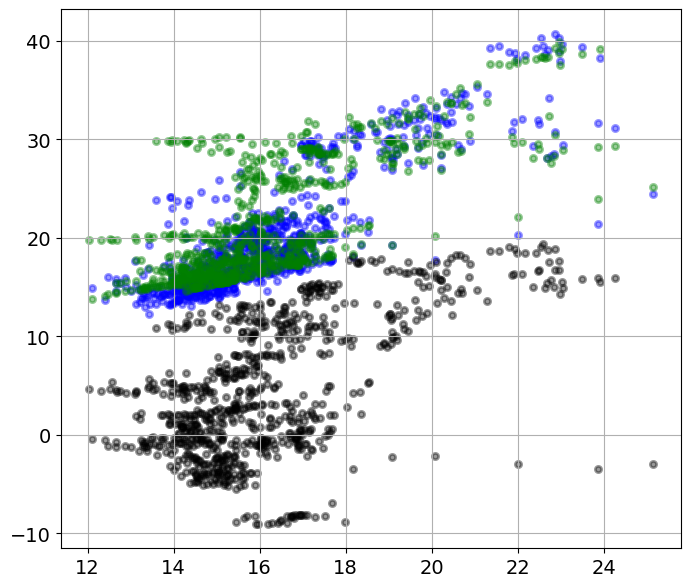

In [8]:
import matplotlib as mpl
mpl.rcParams.update({'figure.figsize':[9,5.4],'axes.grid' : True,'font.size': 14,'savefig.facecolor':'white'})
indx=14;indy=10
#indx=10;indy=14
indx=13;indy=10
X1=ds_seg["ESSB"][:,:,indy,indx].values.flatten().copy()*(0.045/0.002)**2
X2=ds_seg["ESB"][:,:,indy,indx].values.flatten().copy()
X0=ds_seg["Efxfy_model"][:,:,indy,indx].values.flatten().copy()
Y=ds_seg["ESSB"][:,:,10,10].values.flatten().copy()
W=(ds_seg["uncertainty"][:,:].values.flatten()**2)*dxdy*4.376579
logW=10*np.log10(W)

E=ds_seg["Efxfy"][:, :,indy,indx].values.flatten()
XD=ds_seg["noise_250k"][:, :].values.flatten()
YD=ds_seg["noise_250l"][:, :].values.flatten()
logYD=10*np.log10(YD)
logXD=10*np.log10(XD)
logE=10*np.log10(E)


Hs=ds_seg["Hs_model_spec"][:,:].values.flatten().copy()
fac=0.02**2*(256*(8-2*np.pi))/(np.pi)

plt.figure(figsize=(8,7))
#sc = plt.scatter(logW,logXD, c='b', lw=2, s=20, alpha=0.4,label=r'$E_{\min}$')
sc = plt.scatter(logW,logE, c='b', lw=2, s=20, alpha=0.4,label=r'$E_{\min}$')
#sc = plt.scatter(logW,logYD, c='r', lw=2, s=20, alpha=0.4,label=r'$E_{\min}$')
sc = plt.scatter(logW,10*np.log10(X0), c='k', lw=2, s=20, alpha=0.4,label=r'$E_{\min}$')
sc = plt.scatter(logW,10*np.log10(W+X1+X2), c='g', lw=2, s=20, alpha=0.4,label=r'$E_{\min}$')
 

In [9]:
###################################################################
def wavespec_Efth_to_Efxfy_with_surfboard_data(
    efth, modf, moddf, modang, moddth,
    f_xt, f_at, H3,
    kxmax, kymax, dkxf, dkyf,
    dkxr, dkyr, nkxr, nkyr,
    nkx,nky,ESWOT,kx2s,ky2s,depth=3000., doublesided=0, verbose=0,
    trackangle=0, aliasing=True, interp=None,
    beta=0.03, arctant=42, interp2=None
): 
    """
    Converts a model spectrum on a freq,dir grid to a kx,ky grid and applies aliasing and filters to simulate SWOT data, also adds surf board (separate output) 

    Returns:
        Efxfy : SWOT-like spectrum with filters applied
        ESB   : theoretical surf board (WARNING: 4 times smaller than Peral et al. 2015) 
        ESSB  : SSB based on empirical beta value 
        interp: indices for interpolation (to be used in next call) 

    """
    
    Etot=np.sum(np.sum(efth[:,:],axis=1)*moddth*moddf[:])
    Hs=4*np.sqrt(Etot)

    Ekxky,kxm,kym,kx2,ky2,interp=wavespec_Efth_to_Ekxky(efth,modf,moddf,modang,moddth, \
          depth=depth,dkx=dkxf,dky=dkyf,nkx=nkx,nky=nky,doublesided=0,verbose=verbose,trackangle=trackangle,indices=interp)
          
    nxavg=round(dkxr/dkxf)   # number of spectral pixels to average; change of resolution
    nyavg=round(dkyr/dkyf)


    ik1=(nkxr+1)//2;ik2=ik1+nkxr
    jk1=(nkyr+1)//2;jk2=jk1+nkyr

    ishift=(1-np.mod(nkxr,2))
    jshift=(1-np.mod(nkyr,2))
    ix1=int(nkx-kxmax/dkxf)+nxavg*(ishift-1)
    iy1=int(nky-kymax/dkyf)+nyavg*(jshift-1)
    di1=-(nxavg//2); di2=di1+nxavg
    dj1=-(nyavg//2); dj2=dj1+nyavg


# WARNING: ALREADY DOUBLE-SIDED ... if called double-sided before 
# We have to deal with the non-symmetry of the spectrum : hence the np.roll 
    Ekxkyds=(1-0.5*doublesided)*(Ekxky+doublesided*np.fliplr(np.roll( np.flipud(np.roll(Ekxky,-1,axis=0)),-1,axis=1) ))

# Replace long components with SWOT data 

    # Flatten the grids for interpolation
    kx2_flat = kx2.flatten()
    ky2_flat = ky2.flatten()
    kx2s_flat = kx2s.flatten()
    ky2s_flat = ky2s.flatten()
    ESWOT_flat = ESWOT.flatten()

    # Create interpolator
    interp2 = interp2d(kx2s_flat, ky2s_flat, ESWOT_flat, kind='cubic')

    # Interpolate onto the fine grid
    ESWOT_fine = interp2(kx2_flat, ky2_flat)
    Ekxkyds=ESWOT_fine
    
# Computes convolution on unfiltered signal     
    conv = np.fft.ifftshift(signal.fftconvolve(Ekxkyds, Ekxkyds[::-1, ::-1], mode='same')) * (dkxf * dkyf)
    conv2=np.fft.fftshift(conv)
    check=np.sum(Ekxkyds**2*dkxf * dkyf)

    print('test conv in function:',conv[0,0],check,arctant,np.shape(conv))
    ESB=(arctant**2*(2*np.pi*kx2)**2*conv2/2)
    ESSB=beta**2*(256*(8-np.pi))*conv2/(np.pi*Hs**2)

# Coarsening of WW3 spectrum on kx,ky grid 
    Efxfyr = average_spectral_blocks(Ekxkyds, ix1, iy1, di1, dj1, nxavg, nyavg, nkxr, nkyr)
#    kx2r   = average_spectral_blocks(kx2, ix1, iy1, di1, dj1, nxavg, nyavg, nkxr, nkyr)
    ESBr   = average_spectral_blocks(ESB, ix1, iy1, di1, dj1, nxavg, nyavg, nkxr, nkyr)
    ESSBr   = average_spectral_blocks(ESSB, ix1, iy1, di1, dj1, nxavg, nyavg, nkxr, nkyr)

   
# Computes convolution on unfiltered signal     
#    conv = np.fft.ifftshift(signal.fftconvolve(Efxfyr, Efxfyr[::-1, ::-1], mode='same')) * (dkxr * dkyr)
#    conv2=np.fft.fftshift(conv)
#    check=np.sum(Efxfyr**2*dkx * dky)
#    ESBr=(arctant**2*(2*np.pi*kx2r)**2*conv2/2)
#    ESSBr=beta**2*(256*(8-np.pi))*conv2/(np.pi*Hs**2)

    Efxfy_obp_H3=Efxfyr*H3
    ESB_obp_H3=ESBr*H3    
    ESSB_obp_H3=ESSBr*H3 #   ESSB*H3       
    
# 4) Downsample in space to the target spatial frequency
    if aliasing: 
        fx_alias, fy_alias, aliased = compute_aliased_spectrum_2D(f_xt, f_at, Efxfy_obp_H3, 1/0.250, 1/0.235, nrep=1)
        Efxfy=aliased[ik1:ik2,jk1:jk2].T
        fx_alias, fy_alias, aliased = compute_aliased_spectrum_2D(f_xt, f_at, ESB_obp_H3, 1/0.250, 1/0.235, nrep=1)
        ESB=aliased[ik1:ik2,jk1:jk2].T
        fx_alias, fy_alias, aliased  = compute_aliased_spectrum_2D(f_xt, f_at, ESSB_obp_H3, 1/0.250, 1/0.235, nrep=1)
        ESSB=aliased[ik1:ik2,jk1:jk2].T
    else: 
        Efxfy =Efxfy_obp_H3[ik1:ik2,jk1:jk2].T
        ESB   =ESB_obp_H3[ik1:ik2,jk1:jk2].T
        ESSB  =ESSB_obp_H3[ik1:ik2,jk1:jk2].T
    return Efxfy,ESB,ESSB,interp,interp2



In [10]:
###### One example of convolution 

# prepares aliasing calculations :
firstg=0

i=181;s=0  # case b
E = ds_seg["Efxfy"][i, s].values
lo2=ds_seg["lon"][i,s].values
la2=ds_seg["lat"][i,s].values
angt=ds_seg["track_angle"][i,s].values


filetr='/media/ardhuin/FabLinux/WW3-CCI/SWOT_WW3-GLOB-30M_202303_trck.nc'
filetr='/media/ardhuin/FabLinux/WW3-SWOT/GLOBIG/SWOTIG_WW3-GLOB-30M_202307_trck.nc'



#filetr='/media/ardhuin/FabLinux/WW3-SWOT/GLOBAL_REF102040/SWOT_WW3-GLOB-30M_202303_trck.nc'
ds_ww3t = xr.open_dataset(filetr)
#print(ds_ww3t)

modang=np.mod(90-ds_ww3t.direction.values,360)
moddf=ds_ww3t.frequency2.values-ds_ww3t.frequency1.values
modf=ds_ww3t.frequency.values
modnth=np.shape(modang)[0]
moddth=(2*np.pi/modnth)
timec=np.datetime64('2023-07-03T06:43:27.807041');lo2= 229.1592662363636  ;la2=-53.58133710181818
2023-07-03T06:43:55.231449000 229.06829741272725 -130.93170258727275 -55.275478799999995

modspec,indww3,modelfound,timeww3,lonww3,latww3,distww3,U10,Udir,depth=swell.SWOTfind_model_spectrum(ds_ww3t,lo2,la2,timec)

print('Found spec?',lo2,la2,timec,'##',distww3,modelfound,type(modspec))
efth=modspec.values
nIG=25
EIG=np.sum(np.sum(modspec[0:nIG,:],axis=1)*moddth*moddf[0:nIG]).values
Etot=np.sum(np.sum(modspec[:,:],axis=1)*moddth*moddf[:]).values
Hs=4*np.sqrt(Etot)

print('Hs:',Hs,', HIG:',4*np.sqrt(EIG),', U10:',U10)


efth=modspec.values
interp=None
doublesided=1
verbose=0


nkx=600;nky=600;	     # not sure this is always high enough ... 
#nkx=1200;nky=1200;	     # not sure this is always high enough ... 

dkx=kx2s[0,1]-kx2s[0,0]
dky=ky2s[1,0]-ky2s[0,0]

print('dkx:',dkx,dky)
arctant=857*np.mean(1/np.arange(25,45,1)
Efxfy,ESB,ESSB,interp2=swell.wavespec_Efth_to_Efxfy_with_surfboard_data(efth,modf,moddf,modang,moddth, \
        f_xt, f_at, H3,kxmax,kymax,dkx,dky,dkxr,dkyr,nxtile,nytile,nkx,nky,ESWOT,kx2s,ky2s, \
        beta=0.015,arctant=arctant,depth=depth,aliasing=False,doublesided=True,verbose=0,trackangle=angt*np.pi/180,interp=interp)



fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(1,2,1)
im=ax1.pcolormesh(kx2s*1000, ky2s*1000, 10*np.log10(Efxfy/HHO), vmin=0, vmax=50, 
#im=ax1.pcolormesh(kx2s*1000, ky2s*1000, 10*np.log10(Eta_WW3_obp_H2/HH3), vmin=0, vmax=50, 
#im=ax1.pcolormesh(kx2s*1000, ky2s*1000, 10*np.log10(Eta_WW3_obp_H2/HH3), vmin=0, vmax=50, 
#im=ax1.pcolormesh(kx2r*1000, ky2r*1000, 10*np.log10(Eta_WW3), vmin=0, vmax=50,
#im=ax1.pcolormesh(kx2s*1000, ky2s*1000, 10*np.log10(ESSBr/HH3), vmin=0, vmax=50, 
#im=ax1.pcolormesh(kx2r*1000, ky2r*1000, 10*np.log10(ESSBlr), vmin=0, vmax=50,
#im=ax1.pcolormesh(kym*1000, kxm*1000, 10*np.log10(ESSBhr.T), vmin=0, vmax=50, 
#im=ax1.pcolormesh(kym*1000, kxm*1000, 10*np.log10(Ekxky.T), vmin=0, vmax=50, 
#im=ax1.pcolormesh(kym*1000, kxm*1000, 10*np.log10(ESSBhr.T), vmin=0, vmax=50, 
#im=ax1.pcolormesh(kym*1000, kxm*1000, 10*np.log10(E2), vmin=0, vmax=50, 
#im=ax1.pcolormesh(kym*1000, kxm*1000, 10*np.log10(E3), vmin=0, vmax=50, 
                  cmap='viridis', rasterized=True)
plt.colorbar(im, ax=ax1, shrink=0.8)

ax2 = fig.add_subplot(1,2,2, projection='polar', theta_offset=0, theta_direction=1)
im=ax2.pcolormesh(modang*np.pi/180, modf, 10*np.log10(modspec), vmin=-10, vmax=20)
plt.colorbar(im, ax=ax2)

plt.tight_layout()
plt.show()



fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(1,2,1)
#im=ax1.pcolormesh(kym*1000, kxm*1000, 10*np.log10(ESShr), vmin=0, vmax=50, 
im=ax1.pcolormesh(kx2s*1000, ky2s*1000, 10*np.log10(ESB/HHO), vmin=0, vmax=50, 
                  cmap='viridis', rasterized=True)
plt.colorbar(im, ax=ax1, shrink=0.8)

ax2 = fig.add_subplot(1,2,2)
im=ax2.pcolormesh(kx2s*1000, ky2s*1000, 10*np.log10(ESSB/HHO), vmin=0, vmax=50,  cmap='viridis', rasterized=True)
plt.colorbar(im, ax=ax2, shrink=0.8)

plt.tight_layout()
plt.show()


SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (1199458167.py, line 28)

In [ ]:
###### Test various methods and resolutions to compute convolutions

# prepares aliasing calculations :
firstg=0

############ These values are for the 5 km tiles ###########
nX2=80
nY2=84
m=8
n=8
nxtile=nX2*2//m  # cross-track
nytile=nY2*2//n  # along-track
###########################################################

kx2s = ds_seg["fx2D"].as_numpy().values
ky2s = ds_seg["fy2D"].as_numpy().values

kxmax=-2*kx2s[0,0]
kymax=-2*ky2s[0,0]
#print('kxmax:',kxmax,kymax)

nkxr=nxtile      # twice the SWOT range to allow aliasing computation 
nkyr=nytile
dkxr=kxmax/nkxr
dkyr=kymax/(nkyr-1)  # only true in nkyr is odd ?? 

kxr=np.linspace(-nkxr*dkxr,(nkxr-1)*dkxr,nkxr*2)
kyr=np.linspace(-nkyr*dkyr,(nkyr-1)*dkyr,nkyr*2)
fx_wreg=kxr*1000
fy_wreg=kyr*1000
kxr2, kyr2 = np.meshgrid(kxr,kyr,indexing='ij') 

ik1=(nxtile+1)//2;ik2=ik1+nxtile
jk1=(nytile+1)//2;jk2=jk1+nytile
x_xt, w_xt, f_xt, H_xt = get_obp_filter(L_filt = 0.980, f_axis = fx_wreg, plot_flag = False, kernel="parzen")
x_at, w_at, f_at, H_at = get_obp_filter(L_filt = 1, f_axis = fy_wreg, plot_flag = False, kernel="bharris")
x_at, w_at, f_obp, H_ptr = get_obp_filter(L_filt = 3, sampling_in = 0.0125,f_axis = fy_wreg, plot_flag = False, kernel="alejandro_azptr")

H = np.repeat(np.array([H_xt]), len(H_at), axis=0).T * np.repeat(np.array([H_at]), len(H_xt), axis=0)
Hptr = np.repeat(np.array([H_ptr]), len(H_xt), axis=0)
H2=H*Hptr                     # note that when model data is also used, H3 is defined below to include az cut-off 
H3=H2    # OPB and PTR
#H3=Hptr*0+1
Hazc=H3*0+1
HH3=H3[ik1:ik2,jk1:jk2].T
HHP=Hptr[ik1:ik2,jk1:jk2].T
HHO=H[ik1:ik2,jk1:jk2].T

angt=ds_seg["track_angle"][0,0].values
filetr='/media/ardhuin/FabLinux/WW3-CCI/SWOT_WW3-GLOB-30M_202303_trck.nc'
filetr='/media/ardhuin/FabLinux/WW3-SWOT/GLOBIG/SWOTIG_WW3-GLOB-30M_202307_trck.nc'



#filetr='/media/ardhuin/FabLinux/WW3-SWOT/GLOBAL_REF102040/SWOT_WW3-GLOB-30M_202303_trck.nc'
ds_ww3t = xr.open_dataset(filetr)
#print(ds_ww3t)

modang=np.mod(90-ds_ww3t.direction.values,360)
moddf=ds_ww3t.frequency2.values-ds_ww3t.frequency1.values
modf=ds_ww3t.frequency.values
modnth=np.shape(modang)[0]
moddth=(2*np.pi/modnth)
timec=np.datetime64('2023-03-30T21:33:30.832687');lo2=229.1592662363636 ;la2=-53.58133710181818 
timec=np.datetime64('2023-07-02T06:52:49.767811');lo2=229.1592662363636 ;la2=-53.58133710181818

i=181;s=0  # case b
ESWOT = ds_seg["Efxfy"][i, s].values

timec=np.datetime64('2023-07-03T06:43:27.807041');lo2= 229.1592662363636  ;la2=-53.58133710181818

modspec,indww3,modelfound,timeww3,lonww3,latww3,distww3,U10,Udir,depth=swell.SWOTfind_model_spectrum(ds_ww3t,lo2,la2,timec)

print('Found spec?',lo2,la2,timec,'##',distww3,modelfound,type(modspec))
nIG=25
EIG=np.sum(np.sum(modspec[0:nIG,:],axis=1)*moddth*moddf[0:nIG]).values
Etot=np.sum(np.sum(modspec[:,:],axis=1)*moddth*moddf[:]).values
Hs=4*np.sqrt(Etot)

print('Hs:',Hs,', HIG:',4*np.sqrt(EIG),', U10:',U10)


efth=modspec.values
interp=None
doublesided=1
verbose=0


nkx=600;nky=600;	     # not sure this is always high enough ... 
#nkx=1200;nky=1200;	     # not sure this is always high enough ... 


dkx=kx2s[0,1]-kx2s[0,0]
dky=ky2s[1,0]-ky2s[0,0]

dkxf=dkx/3;dkyf=dky/3;   # finer spectral resolution 

print('dkx:',dkxf,dkyf)

Efxfy,ESB,ESSB,interp2=swell.wavespec_Efth_to_Efxfy_with_surfboard(efth,modf,moddf,modang,moddth, \
           f_xt, f_at, H3,kxmax,kymax,dkxf,dkyf,dkxr,dkyr,nxtile,nytile,nkx,nky,depth=depth,aliasing=False,doublesided=True,verbose=0,trackangle=angt*np.pi/180,interp=interp)



#Eta_WW3_obp_H2,interp = \
#                      swell.wavespec_Efth_to_kxky_SWOT_fast(efth,modf,moddf, modang,moddth,f_xt,f_at,H3, \
#                      kxmax,kymax,dkx,dky,dkxr,dkyr,nxtile,nytile,doublesided=0,verbose=0,aliasing=False,trackangle=angt*np.pi/180,interp=interp)

# prepares for convolution ... 



#nkx=1200;nky=1200;	     # not sure this is always high enough ... 

Ekxky,kxm,kym,kx2,ky2,interp2=swell.wavespec_Efth_to_Ekxky(efth,modf,moddf,modang,moddth, \
          depth=depth,dkx=dkxf,dky=dkyf,nkx=nkx,nky=nky,doublesided=0,verbose=verbose,trackangle=angt*np.pi/180,indices=interp)
#print('COUCOU')
#Ekxky,interp2 =      wavespec_Efth_to_kxky_SWOT_fast(efth,modf,moddf, modang,moddth,f_xt,f_at,H3, \
#                      kxmax,kymax,dkx,dky,dkxr,dkyr,nxtile,nytile,doublesided=0,verbose=0,aliasing=False,trackangle=(angt)*np.pi/180,interp=interp)




nxavg=round(dkxr/dkxf)   # number of spectral pixels to average; change of resolution
nyavg=round(dkyr/dkyf)

ik1=(nkxr+1)//2;ik2=ik1+nkxr
jk1=(nkyr+1)//2;jk2=jk1+nkyr

ishift=(1-np.mod(nkxr,2))
jshift=(1-np.mod(nkyr,2))

ix1=int(nkx-kxmax/dkx)+nxavg*(ishift-1)
iy1=int(nky-kymax/dky)+nyavg*(jshift-1)
di1=-(nxavg//2); di2=di1+nxavg
dj1=-(nyavg//2); dj2=dj1+nyavg


# Coarsening of WW3 spectrum on kx,ky grid 
Ekxkyr=np.zeros((nkxr*2,nkyr*2))
Ekxkyp=np.zeros((nkxr*2,nkyr*2))
# We have to deal with the non-symmetry of the spectrum : hence the np.roll 
Ekxkyds=(1-0.5*doublesided)*(Ekxky+doublesided*np.fliplr(np.roll( np.flipud(np.roll(Ekxky,-1,axis=0)),-1,axis=1) ))
# Coarsening of WW3 spectrum on kx,ky grid 
# We have to deal with the non-symmetry of the spectrum for even numbers (nkxr or nkyr) 


# Flatten the grids for interpolation
kx2_flat = kx2.flatten()
ky2_flat = ky2.flatten()
noise_floor = 3000  # Set your threshold here
ESWOT_expanded = np.hstack((ESWOT, ESWOT[:, 0:1]))

ESWOT_expanded[ESWOT_expanded < noise_floor] = 0

kx2s_expanded = np.hstack((kx2s, -1*kx2s[:, 0:1]))
ky2s_expanded = np.hstack((ky2s, ky2s[:, 0:1]))
ESWOT_flat = ESWOT_expanded.flatten()
kx2s_flat = kx2s.flatten()
ky2s_flat = ky2s.flatten()


# Create interpolator
interp2 = RegularGridInterpolator(
    (ky2s[:, 0], kx2s_expanded[0, :]),  # Tuple of 1D arrays for each dimension
    ESWOT_expanded,                      # 2D data
    method='nearest',             # Interpolation method
    bounds_error=False,         # Do not raise error for out-of-bounds
    fill_value=None             # Value for out-of-bounds points
)

# Evaluate on the fine grid
kx2_flat = kx2.flatten()
ky2_flat = ky2.flatten()
points = np.column_stack((ky2_flat, kx2_flat))
ESWOT_fine = interp2(points).reshape(kx2.shape)

Ekxkyds=Ekxkyds*0
#################################################################"
################ Undo aliasing ? ###############"
# Define the kx and ky ranges
kxm_min, kxm_max = -2.20e-3, -1.59e-3
kym_min ,kym_max =-2.20e-3,0

indxM=np.where(kxm >=kx2s[0,0])[0][0]+1
indxP=np.where(kxm >=-kx2s[0,0])[0][0]+3

# Find the indices for kxm between -2.1e-3 and -1.8e-3
kxm_indices = np.where((kxm >= kxm_min) & (kxm <= kxm_max))[0]
kxm_target_indices = indxP+kxm_indices-indxM
# Find the indices for kym < 0
kym_indices = np.where((kym >= kym_min) & (kym <= kym_max) )[0]

kxm_indice2 = np.where((kxm >= -kxm_max) & (kxm <= -kxm_min))[0]
kxm_target_indice2 = indxM+kxm_indice2-indxP
# Find the indices for kym < 0
kym_indice2 = np.where((kym >= -kym_max) & (kym <= -kym_min) )[0]


print('indxM:',indxM,indxP,kx2s[0,0],kxm[indxM],kxm[indxP])

# Extract the region as a 2D block
region1 = ESWOT_fine[np.ix_(kxm_indices, kym_indices)]
region2 = ESWOT_fine[np.ix_(kxm_indice2, kym_indice2)]

I1=-ik1*nxavg+nkx
I2=ik1*nxavg+nkx+1
J1=-jk1*nyavg+nky
J2=jk1*nyavg+nky+1

print('k      :',kxm[I1]*1000,kxm[I2]*1000,kym[J1]*1000,kym[J2]*1000)
Ekxkyds[I1:I2,J1:J2]=ESWOT_fine[I1:I2,J1:J2]

print('source:',kxm_indice2)
print('target:',kxm_target_indice2)
Ekxkyds[np.ix_(kxm_target_indices,kym_indices )] =  np.maximum(region1,Ekxkyds[np.ix_(kxm_target_indices,kym_indices )])
Ekxkyds[np.ix_(kxm_indices, kym_indices)] = 0
Ekxkyds[np.ix_(kxm_target_indice2,kym_indice2 )] =  np.maximum(region2,Ekxkyds[np.ix_(kxm_target_indice2,kym_indice2 )])
Ekxkyds[np.ix_(kxm_indice2, kym_indice2)] = 0
################ END OF Undo aliasing ? ###############"
#################################################################"

conv = np.fft.ifftshift(signal.fftconvolve(Ekxkyds, Ekxkyds[::-1, ::-1], mode='same')) * (dkx * dky)
conv2=np.fft.fftshift(conv)
check=np.sum(Ekxkyds**2*dkx * dky)

arctant=839/20#h*np.mean(1/x)

ESBhr=(arctant**2*(2*np.pi*kx2)**2*conv2/2)
beta=0.01
ESSBhr=beta**2*(256*(8-np.pi))*conv2/(np.pi*Hs**2)
#Ekxky=ESSBhr



print('number of averaged comp:',nxavg,nyavg)
# Extract region once
sub = Ekxkyds[
        ix1+di1 : ix1 + nxavg*(nkxr*2) + di1,
        iy1+dj1 : iy1 + nyavg*(nkyr*2) + dj1]
# Reshape into blocks

print("Shape of Ekxkyds:", Ekxkyds.shape)
print("Indices: ix1={}, iy1={}, di1={}, dj1={}, nxavg={}, nyavg={}, nkxr={}, nkyr={}".format(ix1, iy1, di1, dj1, nxavg, nyavg, nkxr, nkyr))
print("Slice start:", ix1+di1, iy1+dj1)
print("Slice end:", ix1 + nxavg*(nkxr*2) + di1, iy1 + nyavg*(nkyr*2) + dj1)

sub = sub.reshape(nkxr*2, nxavg, nkyr*2, nyavg)

# Average over block dimensions
Eta_WW3 = sub.mean(axis=(1,3))  # this is the WW3 spectrum on SWOT grid (with optional double-sided)
Sw_obp_H3 = Eta_WW3 * H3
Eta_WW3_obp_H2=Sw_obp_H3[ik1:ik2,jk1:jk2].T

subx = kx2[ix1+di1 : ix1 + nxavg*(nkxr*2) + di1,
           iy1+dj1 : iy1 + nyavg*(nkyr*2) + dj1]
subx = subx.reshape(nkxr*2, nxavg, nkyr*2, nyavg)
kx2r = subx.mean(axis=(1,3))  # wavenumber array 
suby = ky2[ix1+di1 : ix1 + nxavg*(nkxr*2) + di1,
           iy1+dj1 : iy1 + nyavg*(nkyr*2) + dj1]
suby = suby.reshape(nkxr*2, nxavg, nkyr*2, nyavg)
ky2r = suby.mean(axis=(1,3))  # wavenumber array 

sub = ESBhr[ix1+di1 : ix1 + nxavg*(nkxr*2) + di1,
           iy1+dj1 : iy1 + nyavg*(nkyr*2) + dj1]
sub = sub.reshape(nkxr*2, nxavg, nkyr*2, nyavg)
ESBlr2 = sub.mean(axis=(1,3))  # wavenumber array 


sub = ESSBhr[ix1+di1 : ix1 + nxavg*(nkxr*2) + di1,
           iy1+dj1 : iy1 + nyavg*(nkyr*2) + dj1]
sub = sub.reshape(nkxr*2, nxavg, nkyr*2, nyavg)
ESSBlr2 = sub.mean(axis=(1,3))  # wavenumber array 


# Computes convolution on unfiltered signal   (low resolution version) 
conv = np.fft.ifftshift(signal.fftconvolve(Eta_WW3, Eta_WW3[::-1, ::-1], mode='same')) * (dkxr * dkyr)
check=np.sum(Eta_WW3**2*dkxr * dkyr)
print('test conv LR:',conv[0,0],check,arctant,np.shape(conv))

conv2=np.fft.fftshift(conv)
ESBlr=(arctant**2*(2*np.pi*kx2r)**2*conv2/2)
ESSBlr=beta**2*(256*(8-np.pi))*conv2/(np.pi*Hs**2)

ESB_obp_H3=ESBlr*H3    
ESSB_obp_H3=ESSBlr*H3 #   ESSB*H3       
ESSBlr2_obp_H3=ESSBlr2*H3 #   ESSB*H3       

ESBr  =ESB_obp_H3[ik1:ik2,jk1:jk2].T
ESSBr  =ESSB_obp_H3[ik1:ik2,jk1:jk2].T

ESSBrlr2  =ESSBlr2_obp_H3[ik1:ik2,jk1:jk2].T



array1=HH3*0+1 # this is the mask for computing parameters ... 
print('TEST:',indww3,modelfound,timeww3,lonww3,latww3,distww3,'##',np.nanmax(modspec.values),np.nanmax(Eta_WW3_obp_H2),np.shape(Eta_WW3_obp_H2),np.shape(kx2s))
H18,Lmm1,LE,Lm,dm,spr,Q18=swell.SWOTspec_to_HsLm(Eta_WW3_obp_H2,kx2s,ky2s,HH3,array1,angt,doublesided=0)    

print('depth:',depth,'max ESSB:', np.nanmax(ESSB),np.nanmax(ESSBrlr2))



fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(1,2,1)
#im=ax1.pcolormesh(kx2s*1000, ky2s*1000, 10*np.log10(ESSBrlr2/HH3), vmin=0, vmax=50, 
#im=ax1.pcolormesh(kx2s*1000, ky2s*1000, 10*np.log10(Eta_WW3_obp_H2/HH3), vmin=0, vmax=50, 
#im=ax1.pcolormesh(kx2s*1000, ky2s*1000, 10*np.log10(Eta_WW3_obp_H2/HH3), vmin=0, vmax=50, 
#im=ax1.pcolormesh(kx2r*1000, ky2r*1000, 10*np.log10(Eta_WW3), vmin=0, vmax=50,
#im=ax1.pcolormesh(kx2s*1000, ky2s*1000, 10*np.log10(ESSBr/HH3), vmin=0, vmax=50, 
#im=ax1.pcolormesh(kx2r*1000, ky2r*1000, 10*np.log10(ESSBlr), vmin=0, vmax=50,
#im=ax1.pcolormesh(kym*1000, kxm*1000, 10*np.log10(ESSBhr.T), vmin=0, vmax=50, 
im=ax1.pcolormesh(kym*1000, kxm*1000, 10*np.log10((Ekxkyds+ESBhr+ESSBhr).T), vmin=0, vmax=50, 
#im=ax1.pcolormesh(kym*1000, kxm*1000, 10*np.log10(ESSBhr.T), vmin=0, vmax=50, 
#im=ax1.pcolormesh(kym*1000, kxm*1000, 10*np.log10(E2), vmin=0, vmax=50, 
#im=ax1.pcolormesh(kym*1000, kxm*1000, 10*np.log10(E3), vmin=0, vmax=50, 
                  cmap='viridis', rasterized=True)
plt.colorbar(im, ax=ax1, shrink=0.8)
ax1.set_xlim([-2.5,2.5]);
ax1.set_ylim([-2.5,2.5]);


ax2 = fig.add_subplot(1,2,2, projection='polar', theta_offset=0, theta_direction=1)
im=ax2.pcolormesh(modang*np.pi/180, modf, 10*np.log10(modspec), vmin=-10, vmax=20)
plt.colorbar(im, ax=ax2)

plt.tight_layout()
plt.show()



fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(1,2,1)
#im=ax1.pcolormesh(kym*1000, kxm*1000, 10*np.log10(ESShr), vmin=0, vmax=50, 
im=ax1.pcolormesh(kx2s*1000, ky2s*1000, 10*np.log10(ESWOT*HHP), vmin=0, vmax=50, 
#im=ax1.pcolormesh(kx2s*1000, ky2s*1000, 10*np.log10(ESShr), vmin=0, vmax=50, 
#im=ax1.pcolormesh(kx2s*1000, ky2s*1000, 10*np.log10(ESSB/HH3), vmin=0, vmax=50, 
#im=ax1.pcolormesh(kym*1000, kxm*1000, 10*np.log10(Ekxky.T), vmin=0, vmax=50, 
#im=ax1.pcolormesh(kym*1000, kxm*1000, 10*np.log10(E2), vmin=0, vmax=50, 
#im=ax1.pcolormesh(kym*1000, kxm*1000, 10*np.log10(E3), vmin=0, vmax=50, 
                  cmap='viridis', rasterized=True)
plt.colorbar(im, ax=ax1, shrink=0.8)

ax2 = fig.add_subplot(1,2,2)
im=ax2.pcolormesh(kx2s*1000, ky2s*1000, 10*np.log10(ESB/HH3), vmin=0, vmax=50,  cmap='viridis', rasterized=True)
plt.colorbar(im, ax=ax2, shrink=0.8)

plt.tight_layout()
plt.show()



In [33]:
1440000/(40*42)

857.1428571428571

In [9]:
print(1.22*np.sqrt(128)/128)

0.1078337841309485


In [10]:
print(10*np.log10(1.125))

0.5115252244738129


In [15]:
tanmid=15/857
fx=1/600
Hc=tanmid/(np.pi*fx)
print(Hc,tanmid)

3.342810940086483 0.01750291715285881


In [16]:
10**(-0.4)

0.3981071705534972

In [15]:
(2*np.pi/240)*0.5

0.01308996938995747

In [16]:
1/0.013

76.92307692307692

In [23]:
0.05*1.4*2*np.pi

0.439822971502571

In [30]:
sigma=1.4*2*np.pi
k=sigma**2/9.81
a=0.02
print(sigma,k,a*k,0.4*50)


8.79645943005142 7.88763491381657 0.1577526982763314 20.0


In [26]:
np.log10(3)

0.47712125471966244

In [29]:
print(2*np.pi/400)

0.015707963267948967
